## Étape 2 : Assemble Data

In [ ]:
from datasets import load_dataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import json

In [3]:
ds=load_dataset("imdb")

In [4]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [5]:
train_df=ds["train"].to_pandas()

In [6]:
train_df.sample(10)

,text,label
7465,The film is a collection of cliche's on just a...,0
218,While it's early to say how the series will ev...,0
5135,Becky Harris plays the female shopper whose mi...,0
13495,Father of the pride is a pleasant surprise: It...,1
21501,I first saw Jake Gyllenhaal in Jarhead (2005) ...,1
20363,The plot of this enjoyable MGM musical is cont...,1
18570,"OK, I overrated it just a bit to offset at lea...",1
763,"We have all been asking ourselves ""why don't t...",0
7741,Literally every aspect of this science-fiction...,0
4349,Wow...I can't believe just how bad ZOMBIE DOOM...,0


In [7]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [8]:
train_df['sentiment'] = np.where(train_df['label'] == 1, 'positive', 'negative')

In [9]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [10]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

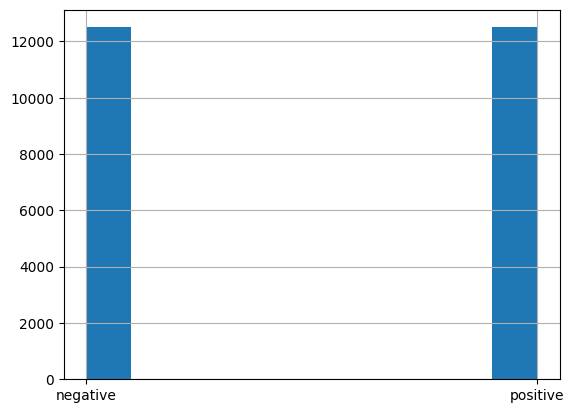

In [11]:
train_df.sentiment.hist()

In [113]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
)

In [114]:
examples_df.shape , gold_examples_df.shape

((20000, 3), (5000, 3))

In [115]:
columns=["text","sentiment"]
gold_examples= (gold_examples_df[columns]
                .sample(20, random_state=34)
                .to_json(orient="records")
                )

In [116]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

## Étape 3 : Élaborer le prompt

In [117]:
user_prompt_template = """```{movie_review}```"""

In [118]:
zero_shot_system_message =""""
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [119]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]

In [120]:
few_shot_system_message ="""
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [121]:
positive_reviews_df=(examples_df[examples_df['sentiment']=='positive'][columns]
                     .sample(4, random_state=34)
                     )

In [122]:
negative_reviews_df=(examples_df[examples_df['sentiment']=='negative'][columns]
                     .sample(4, random_state=34)
                     )

In [123]:
negative_reviews_df

,text,sentiment
2786,Do we really need any more narcissistic garbag...,negative
991,"This movie is so awful, it is hard to find the...",negative
12145,I had high hopes for Troy and I am so bitterly...,negative
11534,If I could i would give ZERO stars for this on...,negative


In [124]:
positive_reviews_df

,text,sentiment
14351,I went to see Antone Fisher not knowing what t...,positive
13676,This is a very good movie. Do you want to know...,positive
21696,Several story lines are interwoven here around...,positive
14251,"""I moved out here to get away from this kind o...",positive


In [125]:
positive_reviews_df.shape, negative_reviews_df.shape

((4, 2), (4, 2))

In [126]:
ex=pd.concat([positive_reviews_df, negative_reviews_df])

In [127]:
examples= ex.sample(4*2, replace=False).to_json(orient="records")

In [128]:
json.loads(examples)

[{'text': '"I moved out here to get away from this kind of thing!" The small town sheriff laments.<br /><br />"This happens a lot in Chicago?" His deputy asks.<br /><br />Well, no, not really. The plot is that a group of Martians mistake a Halloween Rebroadcast of Orson Welles\' War of the Worlds as an account of a real Martian invasion, and conclude they need to get in on the action! What follows are a bunch of mishaps involving the Martian\'s haphazard attempts to conquer the town of "Big Bean, IL". Everyone concludes they are kids in really good costumes, except for the Sheriff\'s daughter and her friend, a kid in a duck suit.<br /><br />The Martians themselves are comical, and you get the impression they are no threat to anyone but themselves pretty early on. It\'s a fun family movie.',
  'sentiment': 'positive'},
 {'text': "This is a very good movie. Do you want to know the real reasons why so many here are knocking this movie? I will tell you. In this movie, you have a black crim

In [129]:
def create_examples(dataset, n=4):
    positive_reviews_df=(dataset[dataset['sentiment']=='positive'][columns]
                     .sample(n, random_state=34)
                     )
    negative_reviews_df=(dataset[dataset['sentiment']=='negative'][columns]
                     .sample(n, random_state=34)
                     )
    examples_df=pd.concat([positive_reviews_df, negative_reviews_df])
    examples= examples_df.sample(2*n, replace=False)
    return examples.to_json(orient="records")

In [132]:
examples=create_examples(examples_df, n=6)
json.loads(examples)

[{'text': "Another powerful chick flick. This time, it revolves around Diana Gusman who is always getting into fights at school. Instead of getting expelled, she takes her anger elsewhere, to the boxing ring. She trains to be a boxer and there she meets featherweight Adrian and begins to fall in love with him. This movie has a powerful message of taking your dreams and going with them even if someone doesn't believe in you (in this case, her dad doesn't believe in her). That alone makes the movie worth the price. Enjoy",
  'sentiment': 'positive'},
 {'text': "If I could i would give ZERO stars for this one, but unfortunately i have to give one...<br /><br />There is no single scene I could laugh about... but the game didn't make me laugh either. So if you're some ill retarded folk, go to your local cinema, watch this movie and give it 10 stars, like some people here already did.<br /><br />but for me... in a movie where children are shot dead to achieve humor... good taste goes over th

In [134]:
def creat_prompt(system_message, examples,user_prompt_template):
    prompt=[
        {'role':'system', 'content': system_message},
    ]
    for example in examples:
        review=example['text']
        sentiment=example['sentiment']
    prompt.append({'role':'user', 'content': user_prompt_template.format(movie_review=review)})
    prompt.append({'role':'assistant', 'content': f"{sentiment}"})
    return prompt

In [137]:
few_shot_prompt = creat_prompt(few_shot_system_message, examples, user_prompt_template)

TypeError: string indices must be integers, not 'str'

In [136]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': "```Several story lines are interwoven here around different women characters. The shoes they wear serve as an indication of their troubled lives. All are transformed at the end of the movie. Adela (Antonia San Juan) leads a brothel; Her daughter Anita (Monica Cervera) is retarded and has a restricted life. Leire (Najwa Nimri) is a shoe designer with problems and loses her boyfriend; Maricarmen (Vicky Peña) has lost her husband and now raises the children from his deceased former wife. Isabel (Ángela Molina) is a bored rich lady.<br /><br />Other characters are used to connect the five main women characters. In storytelling not everything is given away in the beginning: Some connections are est